Upload train.csv and test.csv


Saving test.csv to test.csv
Saving train.csv to train.csv

Uploaded files:
['test.csv', 'train.csv']

Training Dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN

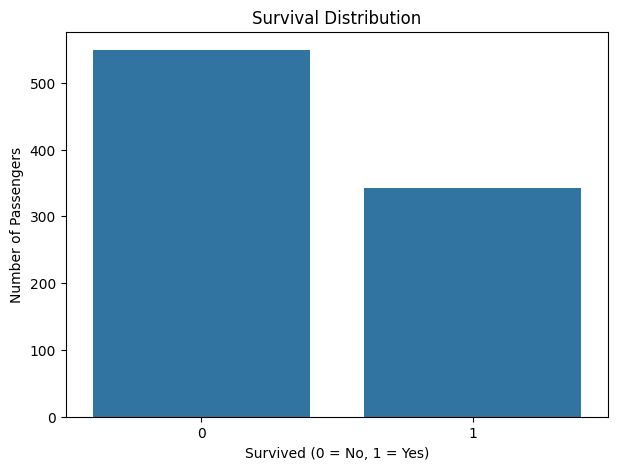

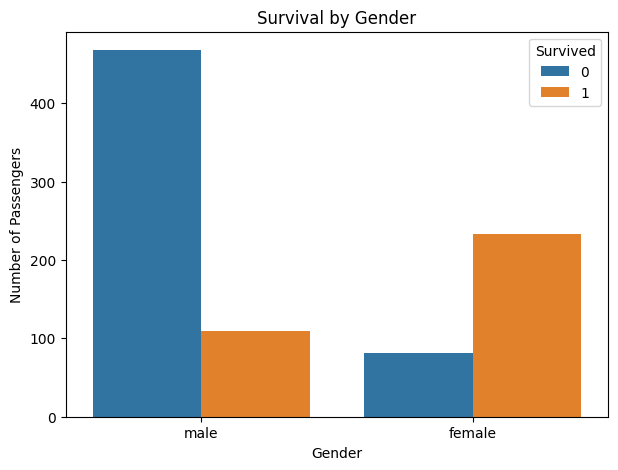

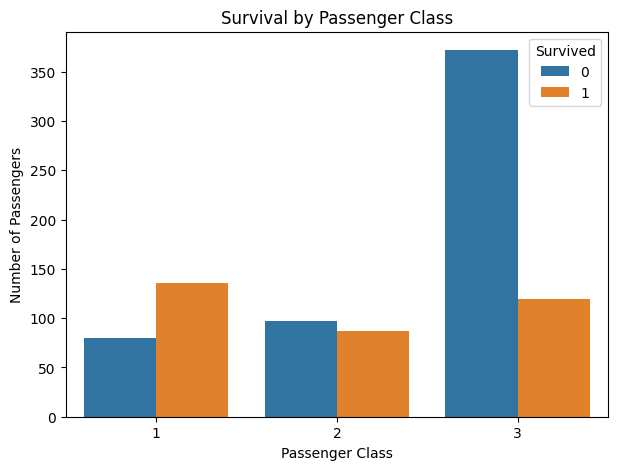

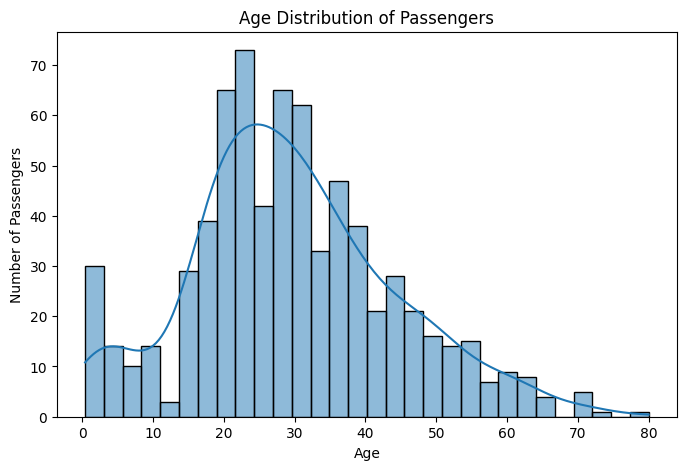

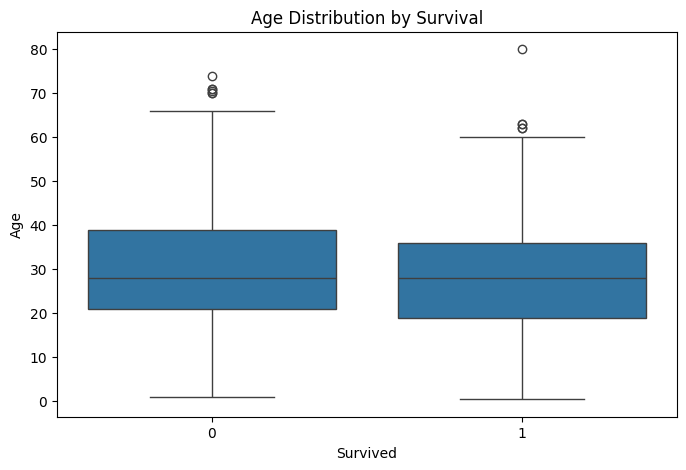

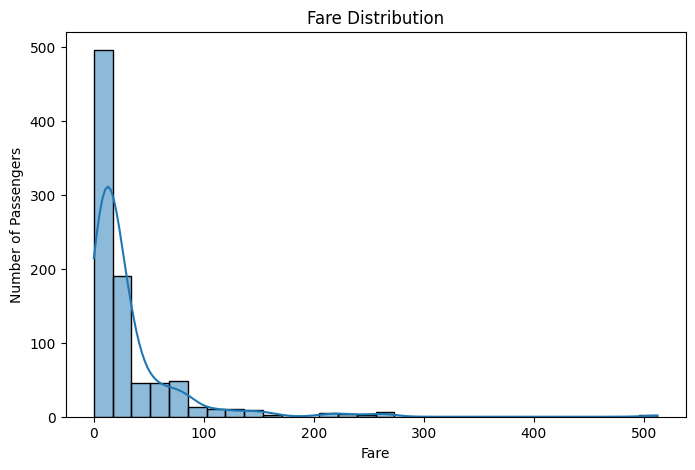

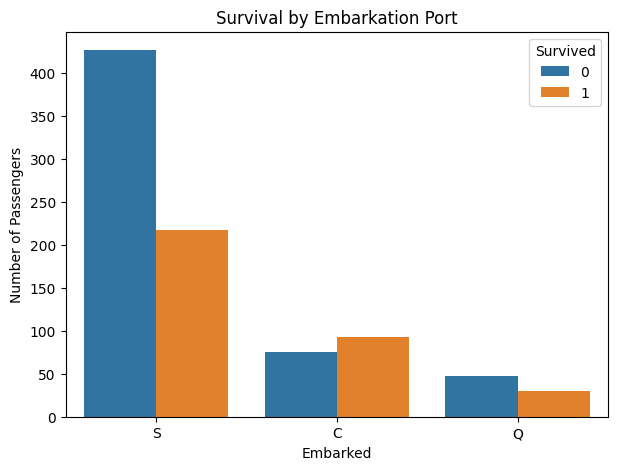

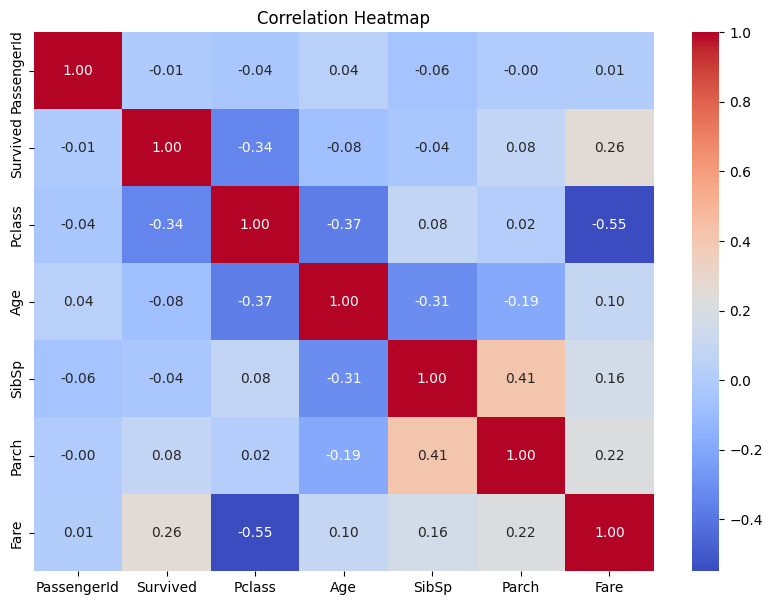


New Features:
   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1

Training Samples: 712
Validation Samples: 179

LOGISTIC REGRESSION
Accuracy: 80.45 %

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


Confusion Matrix:
[[97 13]
 [22 47]]


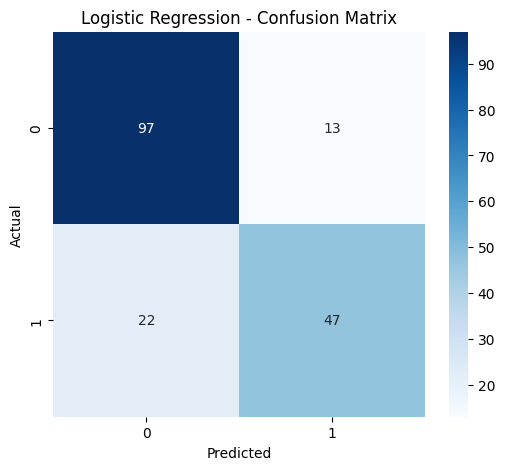


DECISION TREE
Accuracy: 76.54 %

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       110
           1       0.75      0.58      0.66        69

    accuracy                           0.77       179
   macro avg       0.76      0.73      0.74       179
weighted avg       0.76      0.77      0.76       179


Confusion Matrix:
[[97 13]
 [29 40]]

RANDOM FOREST
Accuracy: 81.01 %

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       110
           1       0.81      0.67      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179


Confusion Matrix:
[[99 11]
 [23 46]]


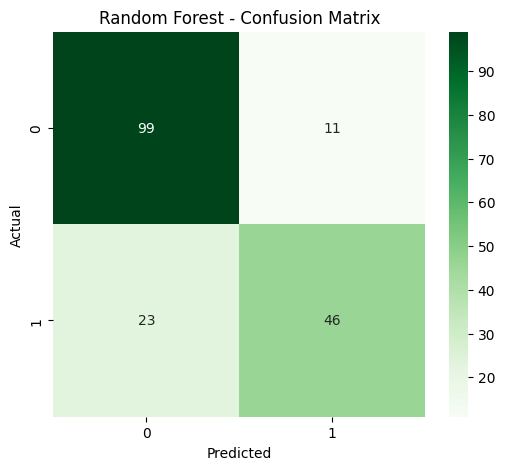


MODEL COMPARISON
                 Model  Accuracy (%)
2        Random Forest     81.005587
0  Logistic Regression     80.446927
1        Decision Tree     76.536313


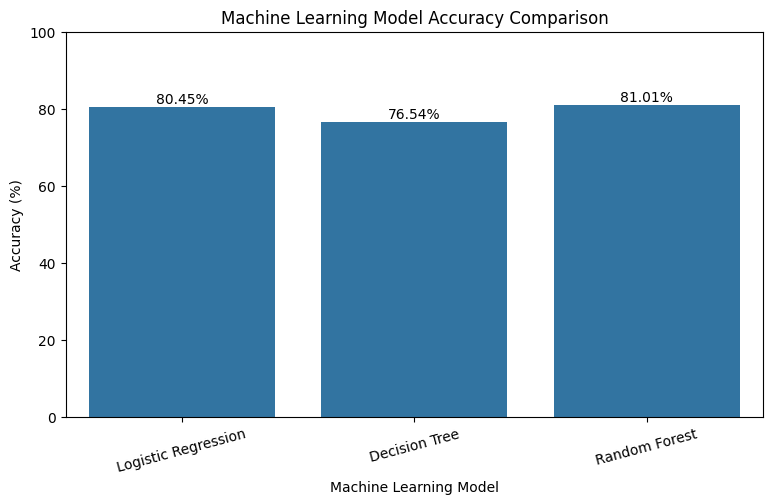


Best Model:
Random Forest

Test Predictions:
[0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 0 1]

Submission File Preview:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         0
7          899         0
8          900         1
9          901         0

Submission file created successfully:
titanic_submission.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



           TITANIC PROJECT COMPLETED

Dataset Information:
Training Dataset Shape: (891, 12)
Testing Dataset Shape: (418, 11)

Models Trained:
1. Logistic Regression
2. Decision Tree
3. Random Forest

Model Accuracies:
Logistic Regression : 80.45 %
Decision Tree : 76.54 %
Random Forest : 81.01 %

Best Performing Model:
Random Forest

Important Features Used:
Pclass, Sex, Age, SibSp, Parch, Fare, Embarked, FamilySize, IsAlone

Feature Engineering Performed:
FamilySize = SibSp + Parch + 1
IsAlone = 1 when FamilySize is 1

Final Observation:
The Titanic survival prediction project demonstrates how data cleaning, exploratory data analysis, feature engineering and machine learning can be combined to build a classification model for predicting passenger survival.


In [1]:
# ============================================================
# TITANIC SURVIVAL PREDICTION - COMPLETE DATA SCIENCE PROJECT
# ============================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")


# =========================
# 2. UPLOAD DATASETS
# =========================

print("Upload train.csv and test.csv")

uploaded = files.upload()

print("\nUploaded files:")
print(list(uploaded.keys()))


# =========================
# 3. LOAD DATASETS
# =========================

train_file = "train.csv"
test_file = "test.csv"

train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

print("\nTraining Dataset:")
print(train_df.head())

print("\nTesting Dataset:")
print(test_df.head())


# =========================
# 4. BASIC DATA EXPLORATION
# =========================

print("\nTraining Dataset Shape:")
print(train_df.shape)

print("\nTesting Dataset Shape:")
print(test_df.shape)

print("\nTraining Dataset Information:")
train_df.info()

print("\nStatistical Summary:")
print(train_df.describe())

print("\nMissing Values:")
print(train_df.isnull().sum())


# =========================
# 5. TARGET VARIABLE ANALYSIS
# =========================

print("\nSurvival Counts:")
print(train_df["Survived"].value_counts())

plt.figure(figsize=(7, 5))
sns.countplot(x="Survived", data=train_df)
plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()


# =========================
# 6. EDA - SURVIVAL BY SEX
# =========================

plt.figure(figsize=(7, 5))
sns.countplot(x="Sex", hue="Survived", data=train_df)
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()


# =========================
# 7. EDA - SURVIVAL BY CLASS
# =========================

plt.figure(figsize=(7, 5))
sns.countplot(x="Pclass", hue="Survived", data=train_df)
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()


# =========================
# 8. EDA - AGE DISTRIBUTION
# =========================

plt.figure(figsize=(8, 5))
sns.histplot(train_df["Age"], bins=30, kde=True)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()


# =========================
# 9. EDA - AGE VS SURVIVAL
# =========================

plt.figure(figsize=(8, 5))
sns.boxplot(x="Survived", y="Age", data=train_df)
plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Age")
plt.show()


# =========================
# 10. EDA - FARE DISTRIBUTION
# =========================

plt.figure(figsize=(8, 5))
sns.histplot(train_df["Fare"], bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()


# =========================
# 11. EDA - SURVIVAL BY EMBARKED PORT
# =========================

plt.figure(figsize=(7, 5))
sns.countplot(x="Embarked", hue="Survived", data=train_df)
plt.title("Survival by Embarkation Port")
plt.xlabel("Embarked")
plt.ylabel("Number of Passengers")
plt.show()


# =========================
# 12. CORRELATION ANALYSIS
# =========================

numeric_df = train_df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()


# =========================
# 13. FEATURE ENGINEERING
# =========================

train = train_df.copy()
test = test_df.copy()

# Family Size
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1
test["FamilySize"] = test["SibSp"] + test["Parch"] + 1

# Is Alone
train["IsAlone"] = np.where(train["FamilySize"] == 1, 1, 0)
test["IsAlone"] = np.where(test["FamilySize"] == 1, 1, 0)

print("\nNew Features:")
print(train[["SibSp", "Parch", "FamilySize", "IsAlone"]].head())


# =========================
# 14. SELECT FEATURES
# =========================

features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone"
]

X = train[features]
y = train["Survived"]

X_test_final = test[features]


# =========================
# 15. IDENTIFY COLUMN TYPES
# =========================

numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone"
]

categorical_features = [
    "Sex",
    "Embarked"
]


# =========================
# 16. PREPROCESSING
# =========================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", __import__("sklearn").preprocessing.OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


# =========================
# 17. TRAIN-TEST SPLIT
# =========================

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", X_train.shape[0])
print("Validation Samples:", X_valid.shape[0])


# =========================
# 18. LOGISTIC REGRESSION
# =========================

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_valid)

logistic_accuracy = accuracy_score(
    y_valid,
    logistic_pred
)

print("\n==============================")
print("LOGISTIC REGRESSION")
print("==============================")

print("Accuracy:", round(logistic_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_valid, logistic_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, logistic_pred))


# =========================
# 19. LOGISTIC REGRESSION CONFUSION MATRIX
# =========================

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_valid, logistic_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# =========================
# 20. DECISION TREE
# =========================

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=5,
                random_state=42
            )
        )
    ]
)

decision_tree_model.fit(X_train, y_train)

decision_tree_pred = decision_tree_model.predict(X_valid)

decision_tree_accuracy = accuracy_score(
    y_valid,
    decision_tree_pred
)

print("\n==============================")
print("DECISION TREE")
print("==============================")

print(
    "Accuracy:",
    round(decision_tree_accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")
print(classification_report(y_valid, decision_tree_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, decision_tree_pred))


# =========================
# 21. RANDOM FOREST
# =========================

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=8,
                random_state=42
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

random_forest_pred = random_forest_model.predict(X_valid)

random_forest_accuracy = accuracy_score(
    y_valid,
    random_forest_pred
)

print("\n==============================")
print("RANDOM FOREST")
print("==============================")

print(
    "Accuracy:",
    round(random_forest_accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")
print(classification_report(y_valid, random_forest_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, random_forest_pred))


# =========================
# 22. RANDOM FOREST CONFUSION MATRIX
# =========================

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_valid, random_forest_pred),
    annot=True,
    fmt="d",
    cmap="Greens"
)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# =========================
# 23. MODEL COMPARISON
# =========================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print(
    results[
        ["Model", "Accuracy (%)"]
    ].sort_values(
        by="Accuracy (%)",
        ascending=False
    )
)


# =========================
# 24. MODEL COMPARISON GRAPH
# =========================

plt.figure(figsize=(9, 5))

sns.barplot(
    x="Model",
    y="Accuracy (%)",
    data=results
)

plt.title("Machine Learning Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=15)

for i, value in enumerate(results["Accuracy (%)"]):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()


# =========================
# 25. SELECT BEST MODEL
# =========================

best_model_name = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]

print("\nBest Model:")
print(best_model_name)


if best_model_name == "Logistic Regression":
    best_model = logistic_model

elif best_model_name == "Decision Tree":
    best_model = decision_tree_model

else:
    best_model = random_forest_model


# =========================
# 26. TRAIN BEST MODEL
# =========================

best_model.fit(X, y)


# =========================
# 27. PREDICT TEST DATA
# =========================

test_predictions = best_model.predict(
    X_test_final
)

print("\nTest Predictions:")
print(test_predictions[:20])


# =========================
# 28. CREATE KAGGLE SUBMISSION
# =========================

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_predictions
})

print("\nSubmission File Preview:")
print(submission.head(10))


# =========================
# 29. SAVE SUBMISSION FILE
# =========================

submission.to_csv(
    "titanic_submission.csv",
    index=False
)

print("\nSubmission file created successfully:")
print("titanic_submission.csv")


# =========================
# 30. DOWNLOAD SUBMISSION
# =========================

files.download("titanic_submission.csv")


# =========================
# 31. FINAL PROJECT SUMMARY
# =========================

print("\n")
print("===================================================")
print("           TITANIC PROJECT COMPLETED")
print("===================================================")

print("\nDataset Information:")
print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

print("\nModels Trained:")
print("1. Logistic Regression")
print("2. Decision Tree")
print("3. Random Forest")

print("\nModel Accuracies:")

for _, row in results.iterrows():
    print(
        row["Model"],
        ":",
        round(row["Accuracy (%)"], 2),
        "%"
    )

print("\nBest Performing Model:")
print(best_model_name)

print("\nImportant Features Used:")
print(
    "Pclass, Sex, Age, SibSp, Parch, Fare, "
    "Embarked, FamilySize, IsAlone"
)

print("\nFeature Engineering Performed:")
print("FamilySize = SibSp + Parch + 1")
print("IsAlone = 1 when FamilySize is 1")

print("\nFinal Observation:")
print(
    "The Titanic survival prediction project demonstrates "
    "how data cleaning, exploratory data analysis, feature "
    "engineering and machine learning can be combined to "
    "build a classification model for predicting passenger survival."
)
